# Archetype clustering experimentation: PCA + Gaussian Mixture

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.ml.archetype_clustering import (
    ArchetypeClusteringConfig,
    ArchetypeClusteringConfigsByRole,
    fit_archetype_clustering,
    numeric_feature_columns,
    prepare_dataframe_for_archetype_clustering,
)
from src.ml.archetype_finetune import (
    grid_sweep_pca_and_gmm,
    pca_cumulative_variance,
    scaled_feature_matrix,
)
from src.pipeline.s3_interaction import gold_player_year_output_key, read_parquet_from_s3

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 200)

## Pitchers — data loading

In [ ]:
ROLE = "pitcher"
YEAR = 2025

S3_BUCKET = "diamond-dna"
GOLD_PREFIX = "gold/statcast"

LOCAL_GOLD_PARQUET: Path | None = None 

RANDOM_STATE = 42
N_INIT = 10
GMM_COVARIANCE_TYPE = "full"

In [12]:
def load_gold_player_year(
    *,
    role: str,
    year: int,
    bucket: str,
    gold_prefix: str,
    local_parquet: Path | None,
) -> pd.DataFrame:
    if local_parquet is not None and local_parquet.is_file():
        df = pd.read_parquet(local_parquet)
    else:
        key = gold_player_year_output_key(gold_prefix, role, year)
        df = read_parquet_from_s3(bucket, key, missing_key_log="warning")
        if df is None:
            raise FileNotFoundError(f"No gold parquet at s3://{bucket}/{key}")
    if "role" not in df.columns:
        df = df.copy()
        df["role"] = role
    return df


gold_df = load_gold_player_year(
    role=ROLE,
    year=YEAR,
    bucket=S3_BUCKET,
    gold_prefix=GOLD_PREFIX,
    local_parquet=LOCAL_GOLD_PARQUET,
)
gold_df.shape

(494, 121)

### Pitchers — feature columns (production rules)

In [13]:
df_idx = prepare_dataframe_for_archetype_clustering(gold_df)
feat_cols = numeric_feature_columns(df_idx)
print(f"n_features = {len(feat_cols)}")
feat_cols

n_features = 30


['batter_chase_rate',
 'batter_contact_rate',
 'batter_swing_rate',
 'batter_whiff_rate',
 'batter_zone_swing_rate',
 'delta_run_exp_mean',
 'edge_percent',
 'fastball_velo_mean',
 'fb_percent_allowed',
 'first_pitch_strike_rate',
 'gb_percent_allowed',
 'iffb_percent_allowed',
 'in_zone_rate',
 'ld_percent_allowed',
 'offspeed_velo_mean',
 'pfx_x_iqr',
 'pfx_z_iqr',
 'pfx_z_mean',
 'pitch_type_entropy',
 'plate_x_mean',
 'plate_x_sd',
 'plate_z_mean',
 'plate_z_sd',
 'platoon_xwoba_allowed_diff',
 'release_extension_iqr',
 'release_extension_mean',
 'release_speed_iqr',
 'release_speed_max',
 'release_spin_rate_iqr',
 'velo_differential']

### Pitchers — cumulative PCA variance

Same probe as the KMeans notebook.

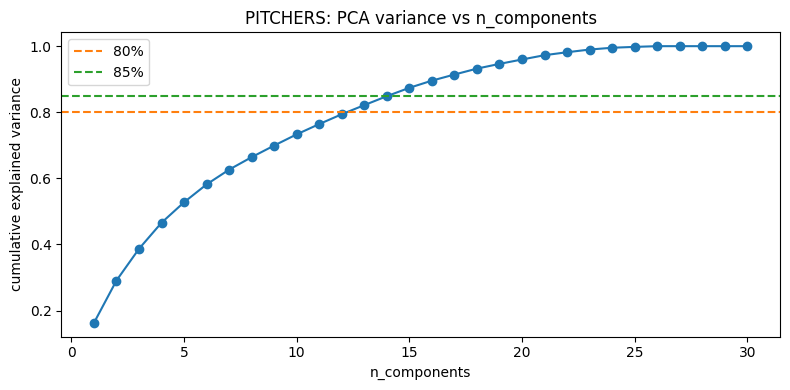

In [14]:
MAX_PC_PROBE = 50

X_scaled, _cols_used, _scaler = scaled_feature_matrix(gold_df)
assert _cols_used == feat_cols

cum, ratios = pca_cumulative_variance(
    X_scaled, max_components=MAX_PC_PROBE, random_state=RANDOM_STATE
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(1, len(cum) + 1), cum, "o-")
ax.axhline(0.80, color="C1", ls="--", label="80%")
ax.axhline(0.85, color="C2", ls="--", label="85%")
ax.set_xlabel("n_components")
ax.set_ylabel("cumulative explained variance")
ax.legend()
ax.set_title("PITCHERS: PCA variance vs n_components")
plt.tight_layout()
plt.show()

### Pitchers — grid sweep: PCA size × GMM `n_components`

In [15]:
PCA_N_COMPONENTS_CANDIDATES_PITCHER = [12, 14, 16, 18, 20]
K_MIN_PITCHER = 6
K_MAX_PITCHER = 12
grid_gmm_pitcher = grid_sweep_pca_and_gmm(
    X_scaled,
    pca_n_components_list=PCA_N_COMPONENTS_CANDIDATES_PITCHER,
    k_min=K_MIN_PITCHER,
    k_max=K_MAX_PITCHER,
    random_state=RANDOM_STATE,
    n_init=N_INIT,
    covariance_type=GMM_COVARIANCE_TYPE,
)

grid_gmm_pitcher.sort_values("gmm_bic", ascending=True).head(25)

,pca_n_components,pca_total_explained_variance,gmm_covariance_type,k,gmm_aic,gmm_bic,gmm_lower_bound,silhouette,davies_bouldin
0,12,0.793997,full,6,19980.347992,22270.729849,-19.120325,0.024896,2.935188
1,12,0.793997,full,7,19945.096414,22617.909003,-18.900468,0.034249,2.833935
2,12,0.793997,full,8,19938.036146,22993.279467,-18.708961,0.026277,2.998361
3,12,0.793997,full,9,20010.412988,23448.087041,-18.598218,0.044270,2.511668
4,12,0.793997,full,10,20014.015587,23834.120373,-18.417373,0.018438,2.877761
5,12,0.793997,full,11,20018.770672,24221.306189,-18.237922,0.027001,2.855990
6,12,0.793997,full,12,19687.776316,24272.742565,-17.718848,0.016354,2.817935
8,14,0.848686,full,7,22121.604963,25647.532262,-20.692438,0.031537,2.549480
7,14,0.848686,full,6,22633.982524,25655.605561,-21.454136,0.016289,3.323511
9,14,0.848686,full,8,22740.447631,26770.679192,-21.076433,0.032572,2.642145


In [17]:
pick = grid_gmm_pitcher.sort_values("gmm_bic", ascending=True).iloc[0]
PCA_N = int(pick["pca_n_components"])
K = int(pick["k"])
print("Suggested (min BIC in grid): PCA_N =", PCA_N, ", n_components =", K)

prod_cfg = ArchetypeClusteringConfig(
    pca_n_components=PCA_N,
    n_clusters=K,
    random_state=RANDOM_STATE,
    n_init=N_INIT,
    covariance_type=GMM_COVARIANCE_TYPE,
)
prod_cfg

Suggested (min BIC in grid): PCA_N = 12 , n_components = 6


ArchetypeClusteringConfig(pca_n_components=12, n_clusters=6, random_state=42, n_init=10, covariance_type='full')

### Pitchers — local fit (matches pipeline)

In [18]:
labeled, meta, bundle = fit_archetype_clustering(
    gold_df, role=ROLE, year=YEAR, config=prod_cfg
)
print("keys:", meta["clustering_method"], "BIC", round(meta["gmm_bic"], 2))
labeled[["player_id", "year", "role", "cluster_id"]].head()

keys: gaussian_mixture BIC 22270.73


,player_id,year,role,cluster_id
0,434378,2025,pitcher,2
1,445276,2025,pitcher,5
2,450203,2025,pitcher,0
3,453286,2025,pitcher,2
4,455119,2025,pitcher,5


## Batters — same workflow as pitchers

In [19]:
ROLE_BAT = "batter"
gold_df_bat = load_gold_player_year(
    role=ROLE_BAT,
    year=YEAR,
    bucket=S3_BUCKET,
    gold_prefix=GOLD_PREFIX,
    local_parquet=LOCAL_GOLD_PARQUET,
)
print("batter shape:", gold_df_bat.shape)

batter shape: (392, 35)


In [20]:
df_idx_bat = prepare_dataframe_for_archetype_clustering(gold_df_bat)
feat_cols_bat = numeric_feature_columns(df_idx_bat)
print(f"[batter] n_features = {len(feat_cols_bat)}")


[batter] n_features = 29


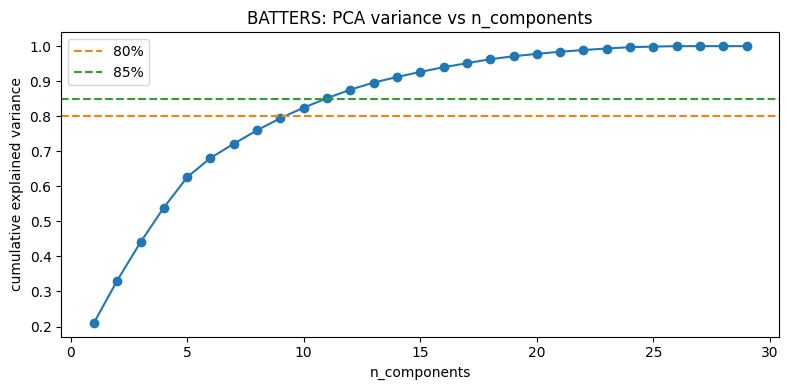

In [21]:
X_scaled_bat, cols_b, _ = scaled_feature_matrix(gold_df_bat)
assert cols_b == feat_cols_bat

cum_b, _ = pca_cumulative_variance(
    X_scaled_bat, max_components=MAX_PC_PROBE, random_state=RANDOM_STATE
)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(1, len(cum_b) + 1), cum_b, "o-")
ax.axhline(0.80, color="C1", ls="--", label="80%")
ax.axhline(0.85, color="C2", ls="--", label="85%")
ax.set_xlabel("n_components")
ax.set_ylabel("cumulative explained variance")
ax.legend()
ax.set_title("BATTERS: PCA variance vs n_components")
plt.tight_layout()
plt.show()


In [23]:
PCA_N_COMPONENTS_CANDIDATES_BAT = [8, 10, 12, 14]
K_MIN_BAT = 6
K_MAX_BAT = 12
grid_gmm_bat = grid_sweep_pca_and_gmm(
    X_scaled_bat,
    pca_n_components_list=PCA_N_COMPONENTS_CANDIDATES_BAT,
    k_min=K_MIN_BAT,
    k_max=K_MAX_BAT,
    random_state=RANDOM_STATE,
    n_init=N_INIT,
    covariance_type=GMM_COVARIANCE_TYPE,
)
grid_gmm_bat.sort_values("gmm_bic", ascending=True).head(25)

,pca_n_components,pca_total_explained_variance,gmm_covariance_type,k,gmm_aic,gmm_bic,gmm_lower_bound,silhouette,davies_bouldin
0,8,0.760062,full,6,11075.210936,12143.480371,-13.440475,0.019947,3.944608
1,8,0.760062,full,7,11097.697509,12344.673727,-13.354565,0.029822,3.134547
2,8,0.760062,full,8,11075.007373,12500.690374,-13.210907,0.019364,2.932757
3,8,0.760062,full,9,11011.424576,12615.814359,-13.015156,0.035406,2.793865
4,8,0.760062,full,10,11070.740567,12853.837133,-12.976223,0.023484,2.716455
5,8,0.760062,full,11,11090.717872,13052.521221,-12.886594,0.032399,2.534708
6,8,0.760062,full,12,10998.704453,13139.214585,-12.654193,0.033628,2.128647
7,10,0.824625,full,6,11783.831151,13352.479578,-14.023589,0.029375,3.108102
8,10,0.824625,full,7,11753.327062,13584.078770,-13.816325,0.038488,2.976304
9,10,0.824625,full,8,11589.938563,13682.793553,-13.439196,0.054873,2.337054


In [24]:
pick_b = grid_gmm_bat.sort_values("gmm_bic", ascending=True).iloc[0]
PCA_N_BAT = int(pick_b["pca_n_components"])
K_BAT = int(pick_b["k"])
print("Suggested [batter] (min BIC): PCA_N =", PCA_N_BAT, ", n_components =", K_BAT)

prod_cfg_bat = ArchetypeClusteringConfig(
    pca_n_components=PCA_N_BAT,
    n_clusters=K_BAT,
    random_state=RANDOM_STATE,
    n_init=N_INIT,
    covariance_type=GMM_COVARIANCE_TYPE,
)
prod_cfg_bat

Suggested [batter] (min BIC): PCA_N = 8 , n_components = 6


ArchetypeClusteringConfig(pca_n_components=8, n_clusters=6, random_state=42, n_init=10, covariance_type='full')

In [25]:
labeled_bat, meta_bat, _bundle_bat = fit_archetype_clustering(
    gold_df_bat, role=ROLE_BAT, year=YEAR, config=prod_cfg_bat
)
print("[batter]", meta_bat["clustering_method"], "BIC", round(meta_bat["gmm_bic"], 2))
labeled_bat[["player_id", "year", "role", "cluster_id"]].head()

[batter] gaussian_mixture BIC 12143.48


,player_id,year,role,cluster_id
0,456781,2025,batter,2
1,457705,2025,batter,2
2,457759,2025,batter,2
3,467793,2025,batter,5
4,500743,2025,batter,5


### Combined `ArchetypeClusteringConfigsByRole` (pitcher vs batter)

In [26]:
pipeline_configs_by_role = ArchetypeClusteringConfigsByRole(
    pitcher=prod_cfg,
    batter=prod_cfg_bat,
)
pipeline_configs_by_role

ArchetypeClusteringConfigsByRole(pitcher=ArchetypeClusteringConfig(pca_n_components=12, n_clusters=6, random_state=42, n_init=10, covariance_type='full'), batter=ArchetypeClusteringConfig(pca_n_components=8, n_clusters=6, random_state=42, n_init=10, covariance_type='full'))